_Copyright (C) 2024 Jagger Alexander_

_This program is free software: you can redistribute it and/or modify it as published._

_This program is distributed in the hope that it will be informative, but without any warranty; without even the implied warranty of merchantability or fitness for a particular purpose._

### Process soil moisture data for ML-based heat wave prediction

1. Import necessary packages
2. Import downloaded soil moisture dataset
3. Plot first time step as example
4. Import USGS HU2 regions and visualize intersection with gridded soil moisture
5. Spatially merge gridded soil moisture data with hydrological region bounds and export for prediction
6. Visualize Texas-Gulf Region soil moisture time series

In [32]:
#1. Import necessary packages
#---

#use !pip install packagename if not found
import xarray as xr
import pandas as pd
import netCDF4 as nc
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import Point


In [25]:
#2. Import downloaded soil moisture dataset
#---

# Open the NetCDF file
# Replace path with your path
sm_df = xr.open_dataset('soil_moisture_filtered.nc')

# Print dataset information
print(sm_df)

<xarray.Dataset> Size: 19MB
Dimensions:        (time: 2336, lat: 32, lon: 64)
Coordinates:
  * time           (time) datetime64[ns] 19kB 2013-03-01 ... 2023-09-30
  * lat            (lat) float32 128B 52.5 51.47 50.44 49.4 ... 22.56 21.53 20.5
  * lon            (lon) float32 256B -130.5 -129.5 -128.5 ... -67.52 -66.5
Data variables:
    soil_moisture  (time, lat, lon) float32 19MB ...
    date           (time) <U10 93kB ...


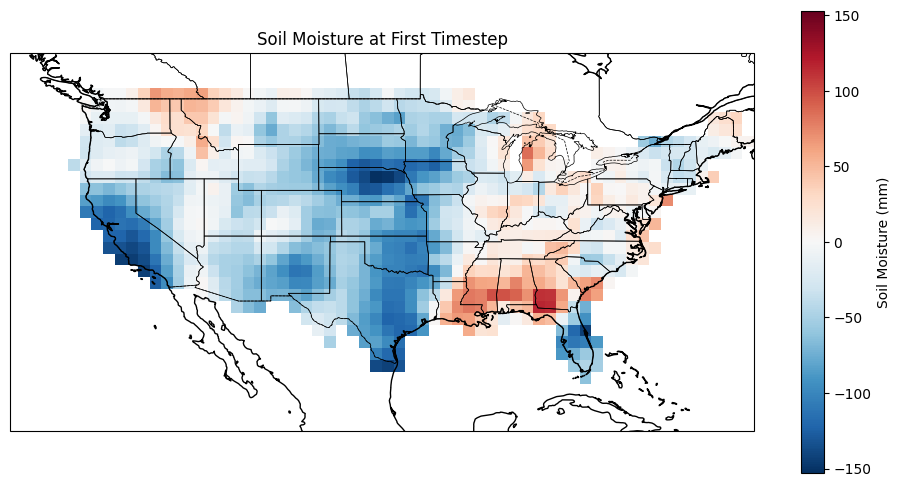

In [18]:
#3. Plot first time step as example
#---

# Select the soil moisture variable
soil_moisture = sm_df['soil_moisture']

# Apply the valid mask
valid_mask = soil_moisture > -1000 
soil_moisture_valid = soil_moisture.where(valid_mask, np.nan)  # Mask invalid values

# Select the first timestep
soil_moisture_first_timestep = soil_moisture_valid.isel(time=0)

# Plot the masked soil moisture
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())  #

soil_moisture_first_timestep.plot(
    ax=ax,
    cbar_kwargs={'label': 'Soil Moisture (mm)'},  
)

# Add features: coastlines, borders, and CONUS outline
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle='--')
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='black')  

plt.title("Soil Moisture at First Timestep")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


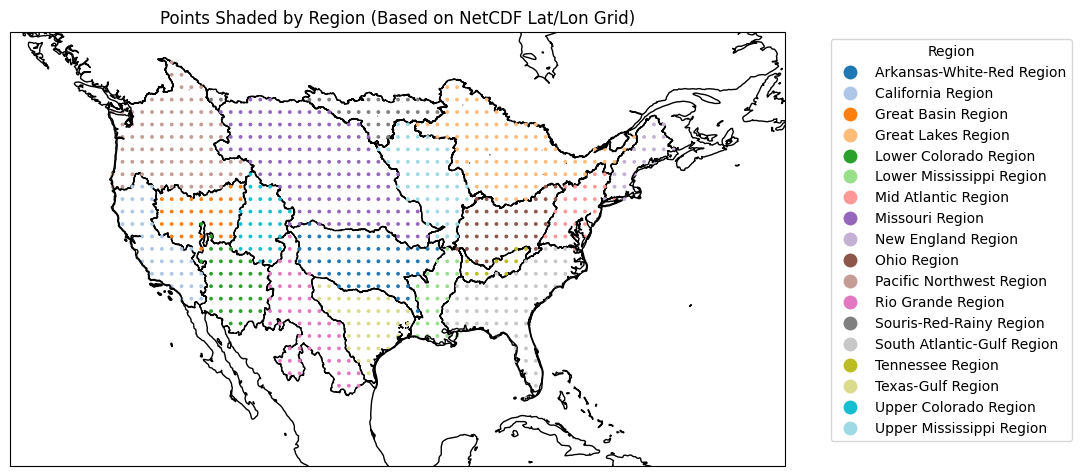

In [41]:
#4. Import USGS HU2 regions and visualize intersection with gridded soil moisture
#---

# Path to the geodatabase
# Replace with your path
gdb_path = r"C:\Users\17753\Documents\AustinClim\waterregion\wbdhu2_a_us_september2023.gdb"

# List all the available layers in the geodatabase
layers = gpd.read_file(gdb_path).keys()
#print("Available layers:", layers)

# Load a specific layer (e.g., the first one)
regions = gpd.read_file(gdb_path)

# Optionally, display the GeoDataFrame
# print(regions.head())

# Extract latitude and longitude from the NetCDF file
lats = sm_df.variables['lat'][:]
lons = sm_df.variables['lon'][:]

# Create a meshgrid of all lat/lon pairs
lon_grid, lat_grid = np.meshgrid(lons, lats)

# Flatten the grids to get pairs of lat/lon points
lat_lon_points = np.vstack([lat_grid.ravel(), lon_grid.ravel()]).T

# Create a GeoDataFrame of the points
geometry = [Point(lon, lat) for lat, lon in lat_lon_points]
gdf_sm = gpd.GeoDataFrame(geometry=geometry, crs="EPSG:4326")


# Ensure both GeoDataFrames are in the same CRS
if gdf_sm.crs != regions.crs:
    gdf_sm = gdf_sm.to_crs(regions.crs)

# Perform spatial join to associate each point with a region
gdf_sm['region'] = gpd.sjoin(gdf_sm, regions, how='left', predicate='intersects')['name']  # Replace 'region_column' with your region column name

# Plot the result, coloring points based on region
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
regions.plot(ax=ax, color='white', edgecolor='black')  # Plot regions
gdf_sm.plot(ax=ax, column='region', cmap='tab20', markersize=3, legend=True, legend_kwds={'bbox_to_anchor': (1.05, 1), 'title': 'Region'})  # Plot points with region colors

# Set x and y limits to focus on CONUS bounds (approximate)
# The approximate CONUS bounds are:
ax.set_xlim(-135, -55)  # Longitude bounds (west to east)
ax.set_ylim(19, 55)     # Latitude bounds (south to north)

ax.add_feature(cfeature.COASTLINE, linestyle='-', edgecolor='black', linewidth=1)  # Coastline

plt.title('Points Shaded by Region (Based on NetCDF Lat/Lon Grid)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()



In [30]:
#5. Spatially merge gridded soil moisture data with hydrological region bounds to get soil moisture time series over each region
#--

# Extract latitude, longitude, and time variables from soil moisture dataframe
lats = sm_df.variables['lat'][:]
lons = sm_df.variables['lon'][:]
dates = sm_df.variables['time'][:]  # Assuming time is in days since 2013-03-01
soil_moisture = sm_df.variables['soil_moisture'][:]

# Create a meshgrid of all lat/lon pairs
lon_grid, lat_grid = np.meshgrid(lons, lats)

# Flatten the grids to get pairs of lat/lon points
lat_lon_points = np.vstack([lat_grid.ravel(), lon_grid.ravel()]).T

# Create a GeoDataFrame of the points
geometry = [Point(lon, lat) for lat, lon in lat_lon_points]
gdf_sm = gpd.GeoDataFrame(geometry=geometry, crs="EPSG:4326")

# Ensure both GeoDataFrames are in the same CRS
if gdf_sm.crs != regions.crs:
    gdf_sm = gdf_sm.to_crs(regions.crs)

# Perform spatial join to associate each point with a region
gdf_sm['region'] = gpd.sjoin(gdf_sm, regions, how='left', predicate='intersects')['name']  # Replace 'name' with the actual region name column

# Prepare to store results
region_names = regions['name'].unique()  # Adjust 'name' to the actual column
averages_by_region = {region: [] for region in region_names}

# Loop through each time step
for t in range(len(times)):
    sm_data = soil_moisture[t, :, :].values  # Extract soil moisture for this time step
    sm_data = sm_data.flatten()  # Flatten to match the lat/lon points
    
    valid_mask = sm_data > -1000  # Only keep valid data points
    gdf_sm['soil_moisture'] = np.where(valid_mask, sm_data, np.nan)  # Assign data to GeoDataFrame

    # Average soil moisture by region
    for region in region_names:
        region_data = gdf_sm[gdf_sm['region'] == region]['soil_moisture']
        avg_sm = region_data.mean()  # Average soil moisture for the region at this time step
        averages_by_region[region].append(avg_sm)

# Create a DataFrame to store the results
averages_by_region = pd.DataFrame(averages_by_region)
averages_by_region['date'] = dates

# Save to CSV
# Replace with your output path
averages_by_region.to_csv('region_soil_moisture_averages.csv', index=False)

print("CSV file saved as 'region_soil_moisture_averages.csv'")


CSV file saved as 'region_soil_moisture_averages.csv'


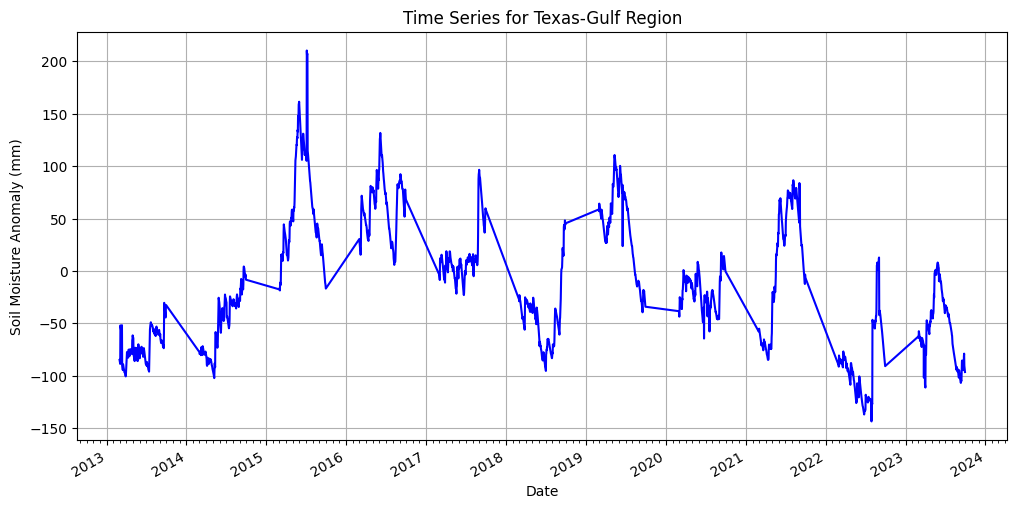

In [42]:
#6. Visualize Texas-Gulf Region soil moisture time series
#---

# Extract time series for the "Texas-Gulf Region"
averages_by_region['date'] = pd.to_datetime(df['date'])  # Convert the 'date' column to datetime
texas_gulf_series = averages_by_region[['date', 'Texas-Gulf Region']].copy()  # Extract the relevant columns

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(texas_gulf_series['date'], texas_gulf_series['Texas-Gulf Region'], linestyle='-', color='b')

# Formatting the x-axis to show every year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate() 

plt.title('Time Series for Texas-Gulf Region')
plt.xlabel('Date')
plt.ylabel('Soil Moisture Anomaly (mm)')
plt.grid(True)
plt.show()